# 04 — Combat Statistics

> **Key question**: What is the value range of each stat, and which types dominate in each combat role?

Understanding stat ranges helps us identify what "excellent" looks like for each attribute,
and which types to prioritise depending on the team role we need to fill.

**Prerequisite**: run `01_data_loading_cleaning.ipynb` first.


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import pickle

plt.rcParams.update({
    'figure.dpi': 130, 'figure.facecolor': 'white',
    'axes.facecolor': '#F5F6FA', 'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.3, 'grid.linestyle': '--',
    'font.family': 'DejaVu Sans', 'axes.titlesize': 13, 'axes.titleweight': 'bold',
    'axes.labelsize': 10, 'xtick.labelsize': 9, 'ytick.labelsize': 9,
})

STATS = ['hp', 'attack', 'defense', 'special-attack', 'special-defense', 'speed']
STAT_LABELS = {
    'hp': 'HP', 'attack': 'Attack', 'defense': 'Defense',
    'special-attack': 'Sp. Atk', 'special-defense': 'Sp. Def', 'speed': 'Speed'
}
STAT_COLORS = ['#E74C3C', '#E67E22', '#3498DB', '#9B59B6', '#1ABC9C', '#F1C40F']
TYPE_COLORS = {
    'normal': '#A8A878', 'fire': '#F08030', 'water': '#6890F0', 'electric': '#F8D030',
    'grass': '#78C850', 'ice': '#98D8D8', 'fighting': '#C03028', 'poison': '#A040A0',
    'ground': '#E0C068', 'flying': '#A890F0', 'psychic': '#F85888', 'bug': '#A8B820',
    'rock': '#B8A038', 'ghost': '#705898', 'dragon': '#7038F8', 'dark': '#705848',
    'steel': '#B8B8D0', 'fairy': '#EE99AC',
}

with open('../data/pokemon_processed.pkl', 'rb') as f:
    df = pickle.load(f)
print(f'Data loaded: {df.shape[0]} Pokémon')

Data loaded: 1025 Pokémon


## 1. Distribution of the 6 base stats — What is a good value?

Each histogram shows the range of values for one stat across all Pokémon.
The coloured zone marks the **top 25%** — those are the values we should aim for in our team.


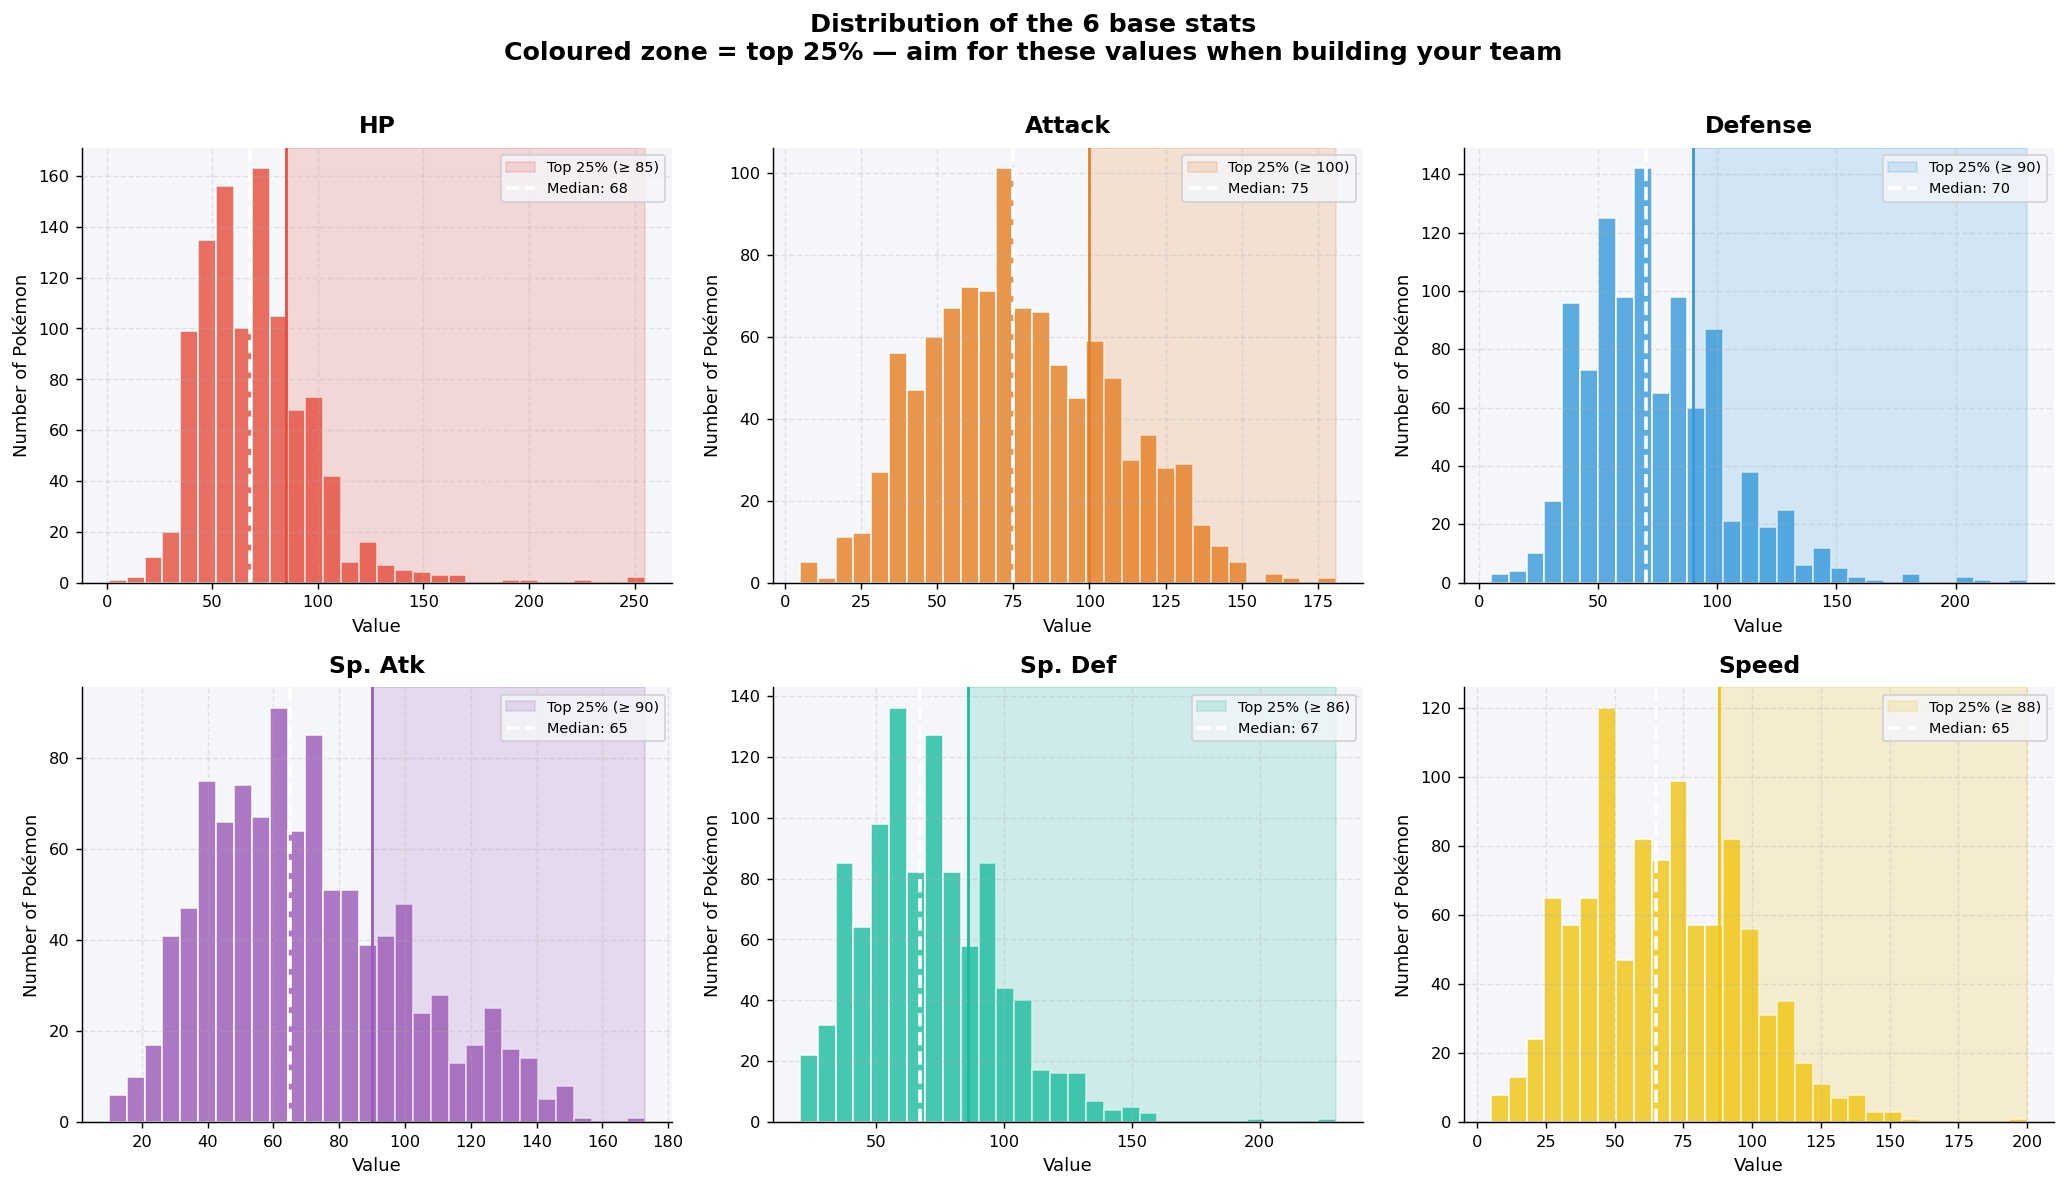

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for ax, stat, color in zip(axes, STATS, STAT_COLORS):
    data = df[stat].dropna()
    q75  = data.quantile(0.75)
    med  = data.median()

    ax.hist(data, bins=30, color=color, edgecolor='white', alpha=0.80)

    ax.axvspan(q75, data.max(), alpha=0.18, color=color,
               label=f'Top 25% (≥ {q75:.0f})')
    ax.axvline(med, color='white', linestyle='--', linewidth=2,
               label=f'Median: {med:.0f}')
    ax.axvline(q75, color=color, linestyle='-', linewidth=1.5)

    ax.set_title(STAT_LABELS[stat], pad=8)
    ax.set_xlabel('Value')
    ax.set_ylabel('Number of Pokémon')
    ax.legend(fontsize=8, loc='upper right')

plt.suptitle(
    'Distribution of the 6 base stats\nColoured zone = top 25% — aim for these values when building your team',
    fontsize=14, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.show()

## 2. BST by primary type — Which types are strongest overall?

Box plots show the distribution of BST for each type. The box spans the middle 50% of Pokémon.
Types at the top are more likely to give us powerful team members.


/tmp/ipykernel_156380/3474625965.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


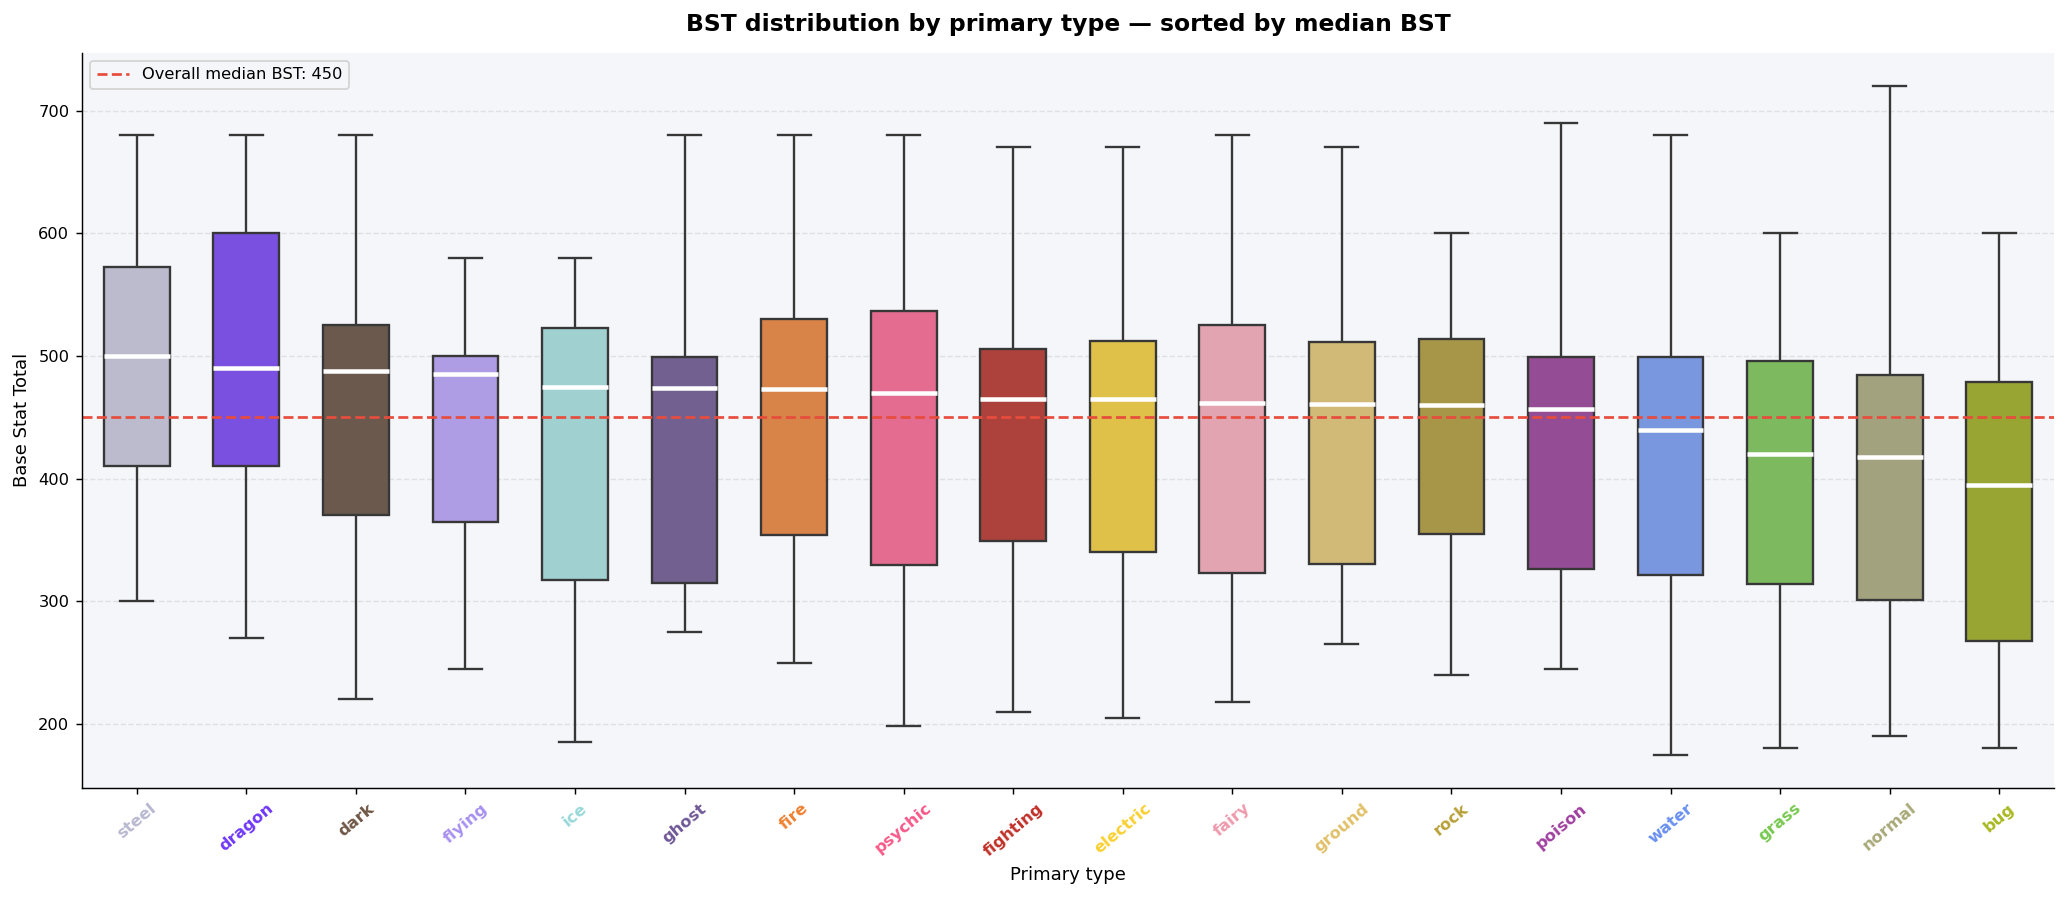

In [13]:
type_order = df.groupby('type1')['bst'].median().sort_values(ascending=False).index.tolist()
palette    = {t: TYPE_COLORS.get(t, '#888') for t in type_order}

fig, ax = plt.subplots(figsize=(16, 7))
sns.boxplot(
    data=df, x='type1', y='bst',
    order=type_order,
    palette=palette,
    width=0.6,
    linewidth=1.3,
    flierprops=dict(marker='o', markersize=3, alpha=0.4),
    medianprops=dict(color='white', linewidth=2.5),
    ax=ax
)
ax.set_title('BST distribution by primary type — sorted by median BST', pad=12)
ax.set_xlabel('Primary type')
ax.set_ylabel('Base Stat Total')
ax.tick_params(axis='x', rotation=40)

for label, t in zip(ax.get_xticklabels(), type_order):
    label.set_color(TYPE_COLORS.get(t, '#333'))
    label.set_fontweight('bold')

ax.axhline(df['bst'].median(), color='#E74C3C', linestyle='--', linewidth=1.5,
           label=f'Overall median BST: {df["bst"].median():.0f}')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## 3. Combat role map — Offensive vs Defensive specialisation per type

Types in the **top-right** are balanced. Types to the **right** are fast sweepers. Types to the **top** are physical tanks.
This scatter helps pick types with **complementary roles** for the team.


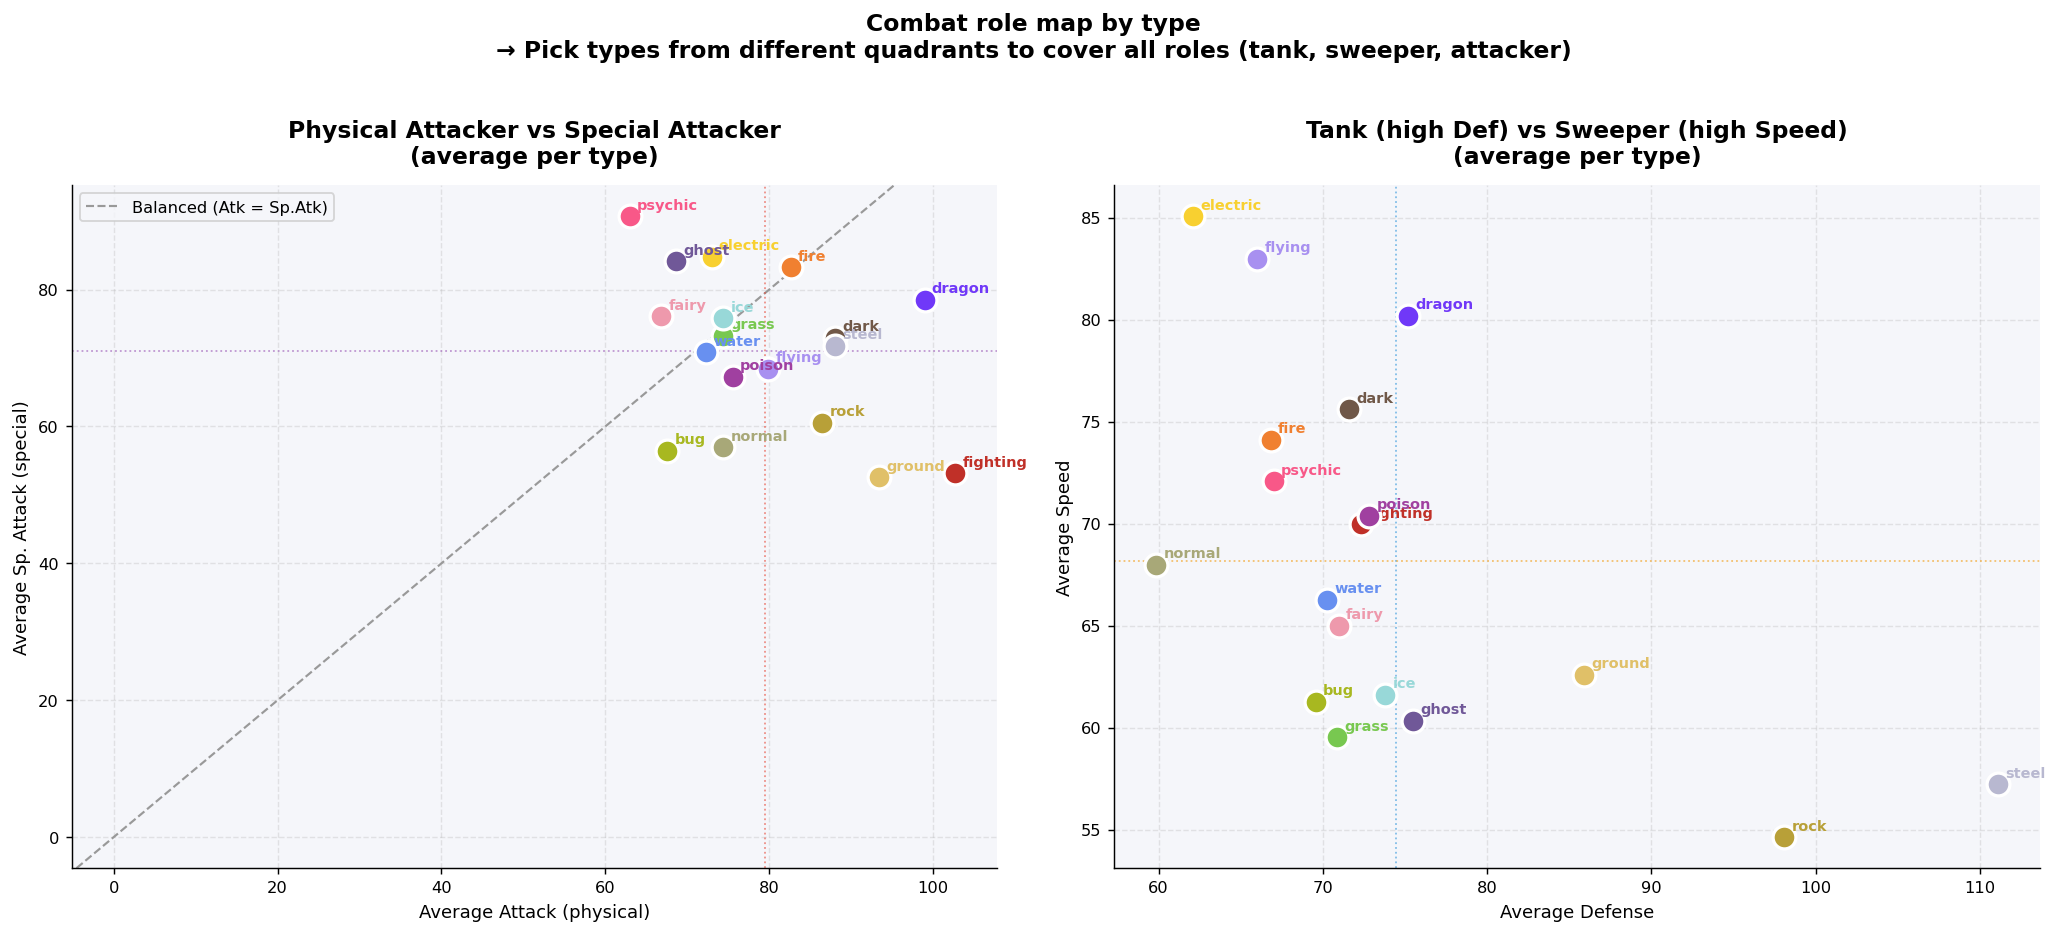

In [14]:
type_means = df.groupby('type1')[STATS].mean()

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

ax = axes[0]
global_mean_atk = type_means[['attack', 'special-attack']].values.mean()
for t, row in type_means.iterrows():
    c = TYPE_COLORS.get(t, '#888')
    ax.scatter(row['attack'], row['special-attack'], color=c, s=160, zorder=3,
               edgecolors='white', linewidth=1.8)
    ax.annotate(t, (row['attack'], row['special-attack']),
                xytext=(4, 4), textcoords='offset points',
                fontsize=8, color=c, fontweight='bold')
ax.axline((0, 0), slope=1, color='#999', linestyle='--', linewidth=1.2,
          label='Balanced (Atk = Sp.Atk)')
ax.axvline(type_means['attack'].mean(), color='#E74C3C', linestyle=':', linewidth=1,
           alpha=0.6)
ax.axhline(type_means['special-attack'].mean(), color='#9B59B6', linestyle=':', linewidth=1,
           alpha=0.6)
ax.set_title('Physical Attacker vs Special Attacker\n(average per type)', pad=12)
ax.set_xlabel('Average Attack (physical)')
ax.set_ylabel('Average Sp. Attack (special)')
ax.legend(fontsize=9)

ax2 = axes[1]
for t, row in type_means.iterrows():
    c = TYPE_COLORS.get(t, '#888')
    ax2.scatter(row['defense'], row['speed'], color=c, s=160, zorder=3,
                edgecolors='white', linewidth=1.8)
    ax2.annotate(t, (row['defense'], row['speed']),
                 xytext=(4, 4), textcoords='offset points',
                 fontsize=8, color=c, fontweight='bold')
ax2.axvline(type_means['defense'].mean(), color='#3498DB', linestyle=':', linewidth=1, alpha=0.6)
ax2.axhline(type_means['speed'].mean(),   color='#F39C12', linestyle=':', linewidth=1, alpha=0.6)
ax2.set_title('Tank (high Def) vs Sweeper (high Speed)\n(average per type)', pad=12)
ax2.set_xlabel('Average Defense')
ax2.set_ylabel('Average Speed')

plt.suptitle(
    'Combat role map by type\n'
    '→ Pick types from different quadrants to cover all roles (tank, sweeper, attacker)',
    fontsize=13, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.show()

## 4. Average stats heatmap by type — Complete role overview


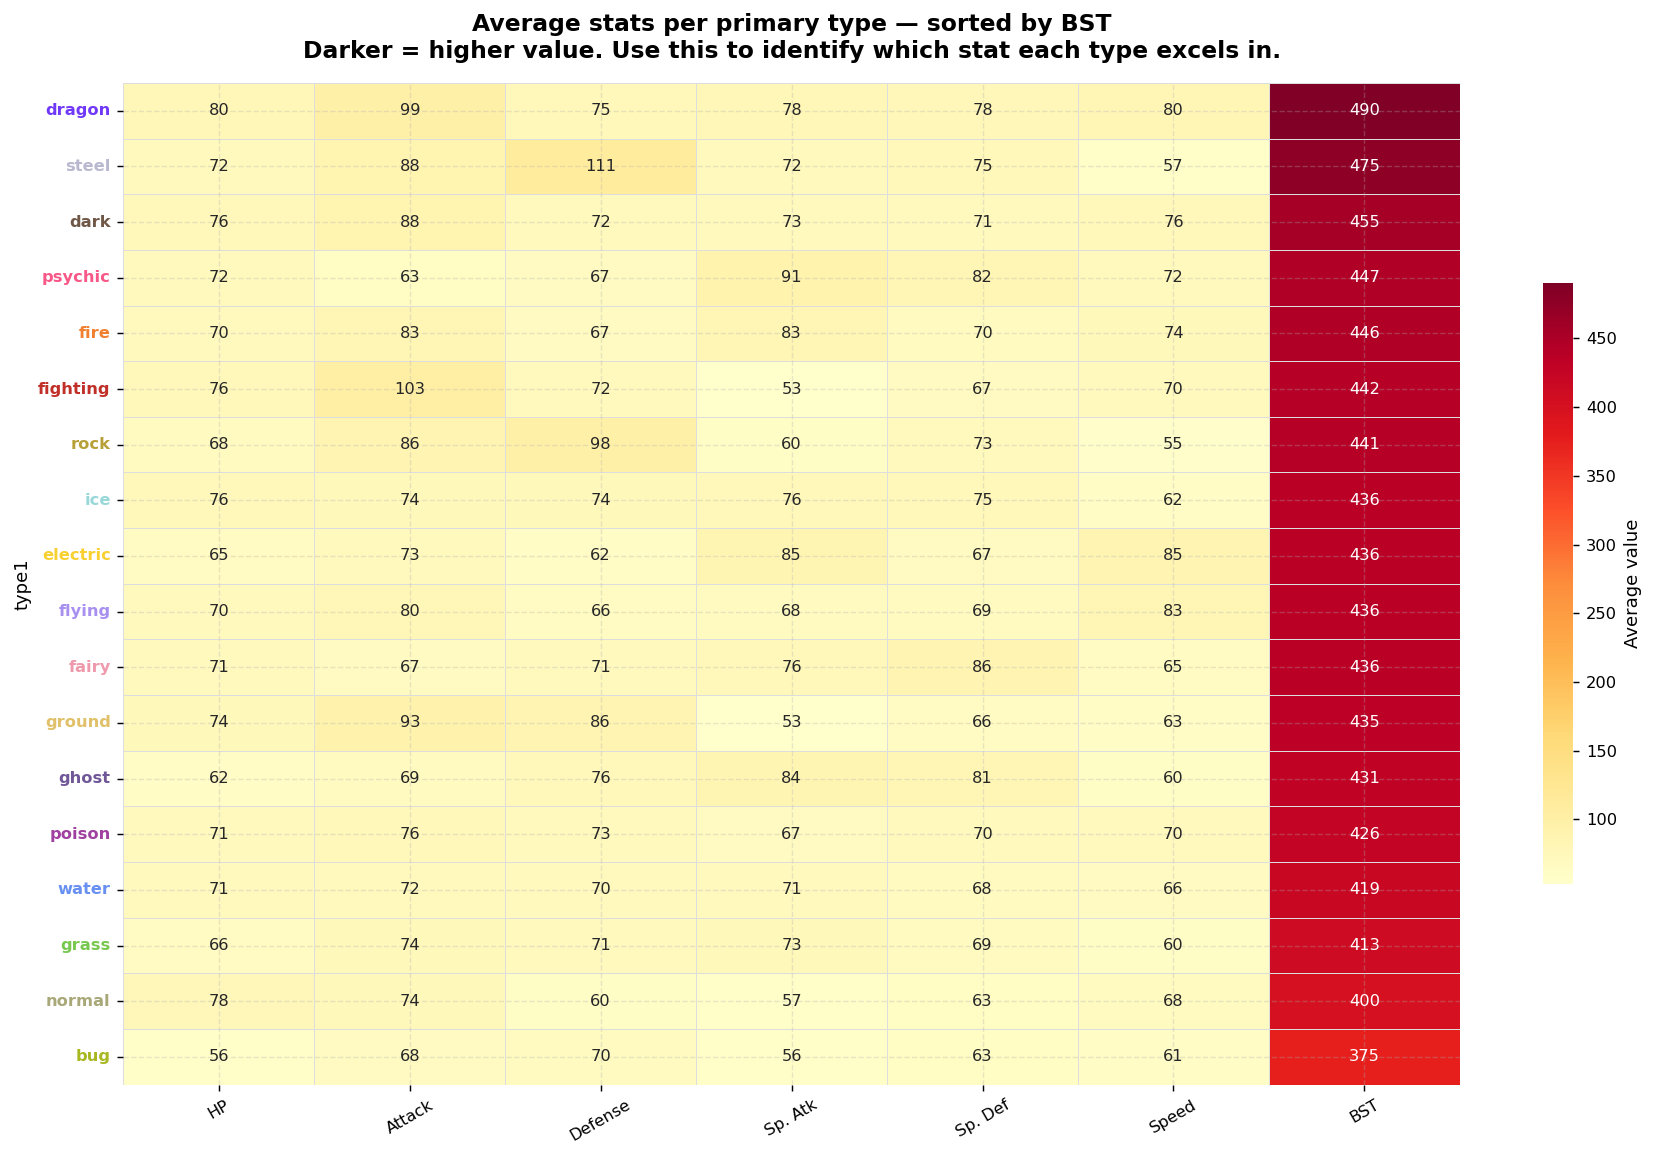

In [15]:
hm_data = df.groupby('type1')[STATS].mean().round(1)
hm_data.columns = [STAT_LABELS[s] for s in STATS]
hm_data['BST'] = df.groupby('type1')['bst'].mean().round(1)
hm_data = hm_data.sort_values('BST', ascending=False)

fig, ax = plt.subplots(figsize=(14, 9))
sns.heatmap(
    hm_data,
    annot=True, fmt='.0f', annot_kws={'size': 9},
    cmap='YlOrRd',
    linewidths=0.4, linecolor='#ddd',
    ax=ax,
    cbar_kws={'shrink': 0.6, 'label': 'Average value'}
)
ax.set_title(
    'Average stats per primary type — sorted by BST\n'
    'Darker = higher value. Use this to identify which stat each type excels in.',
    pad=14
)
ax.tick_params(axis='x', rotation=30)
ax.tick_params(axis='y', rotation=0)
for i, t in enumerate(hm_data.index):
    ax.get_yticklabels()[i].set_color(TYPE_COLORS.get(t, '#333'))
    ax.get_yticklabels()[i].set_fontweight('bold')
plt.tight_layout()
plt.show()